In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

#import os
#for dirname, _, filenames in os.walk('/kaggle/input'):
 #   for filename in filenames:
  #      print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
df=pd.read_csv('/kaggle/input/datasets/akshaydattatraykhare/diabetes-dataset/diabetes.csv')
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [3]:
from sklearn.model_selection import train_test_split
X=df.drop('Outcome',axis=1)
y=df['Outcome']
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(),
    'XGBoost':XGBClassifier(random_state=42,eval_metric='logloss')
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name}: {acc:.4f}")

Logistic Regression: 0.7468
Random Forest: 0.7468
Decision Tree: 0.7532
KNN: 0.6623
XGBoost: 0.7208


In [5]:
from sklearn.model_selection import cross_val_score

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5)
    print(f"{name}: {scores.mean():.4f} (+/- {scores.std():.4f})")

Logistic Regression: 0.7722 (+/- 0.0224)
Random Forest: 0.7540 (+/- 0.0422)
Decision Tree: 0.7188 (+/- 0.0401)
KNN: 0.7240 (+/- 0.0202)
XGBoost: 0.7410 (+/- 0.0381)


In [6]:
from sklearn.metrics import accuracy_score
y_prob=model.predict_proba(x_test)[:,1]
y_pred=(y_prob>0.395).astype(int)
print('Accuracy:',accuracy_score(y_test,y_pred))

Accuracy: 0.487012987012987


In [7]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[60 39]
 [40 15]]
              precision    recall  f1-score   support

           0       0.60      0.61      0.60        99
           1       0.28      0.27      0.28        55

    accuracy                           0.49       154
   macro avg       0.44      0.44      0.44       154
weighted avg       0.48      0.49      0.49       154



In [8]:
from sklearn.metrics import roc_auc_score
y_pred_proba=model.predict_proba(X_test)[:,1]
auc=roc_auc_score(y_test,y_pred_proba)
print('ROC-AUC:',auc)

ROC-AUC: 0.7761248852157944


In [9]:
#Feature Importance
rf_model=RandomForestClassifier()
rf_model.fit(X_train,y_train)
importances=rf_model.feature_importances_
features=X_train.columns
feat_df=pd.DataFrame({'Feature':features,'Importance':importances})
feat_df=feat_df.sort_values(by='Importance',ascending=False)
print(feat_df)

                    Feature  Importance
1                   Glucose    0.253948
5                       BMI    0.161559
7                       Age    0.145857
6  DiabetesPedigreeFunction    0.121907
2             BloodPressure    0.088973
0               Pregnancies    0.082062
4                   Insulin    0.078189
3             SkinThickness    0.067505


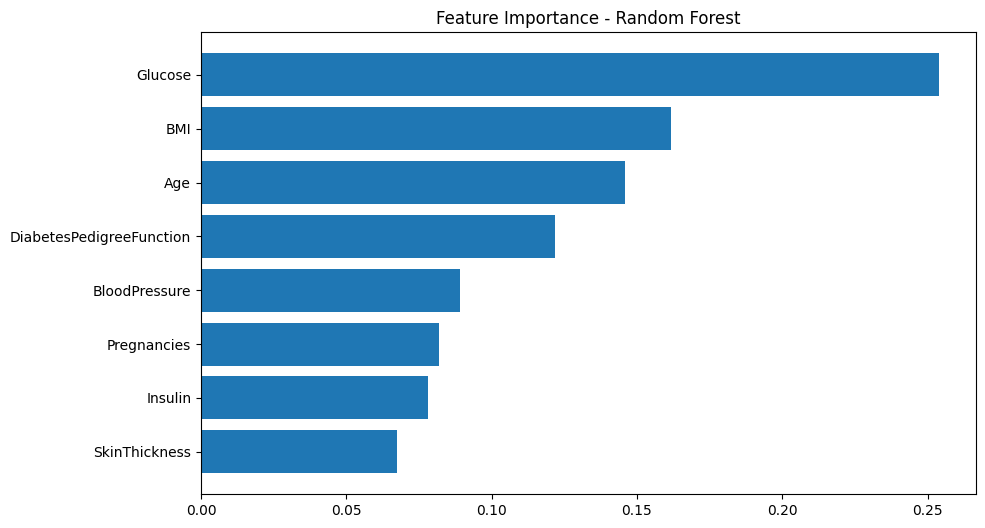

In [10]:
plt.figure(figsize=(10,6))
plt.barh(feat_df["Feature"], feat_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance - Random Forest")
plt.show()